# Initial Database

Files required to run this notebook


*   best_logistic_pipeline.joblib (third-party classification pipeline)
*   final_keywords.json
*   play_store_top_kids_app_games.csv from kaggle
*   df_ml dataset from Permpress



## Import Libraries


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

!pip install google-play-scraper fpdf transformers datasets nltk scikit-learn tqdm joblib --quiet


import ast
import json
import logging
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from itertools import chain
from pathlib import Path
import chardet
import joblib
import numpy as np
import openpyxl
import pandas as pd
import requests
import torch
from torch.utils.data import DataLoader
import warnings
from bs4 import BeautifulSoup
from fpdf import FPDF
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm
auto_tqdm.pandas()
from transformers import (BertTokenizerFast, logging as transformers_logging,
                          pipeline)

from google_play_scraper import app, permissions, search

from huggingface_hub import hf_hub_download






     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=adea153450c97f295e52579f14ccf7c2594d348ea437a6fcb0f8f6a8fc6d1a6e
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf
Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Util

In [ ]:
print("loading utils.py")


def fetch_info(app_id):
    try:
        info = app(app_id)
        perm = permissions(app_id)
        return {
            "APP_ID": app_id,
            "App Name": info["title"],
            "Icon URL": info["icon"],
            "Category": info["genreId"],
            "Age Group": info["contentRating"],
            "Policy Link": info['privacyPolicy'],
            "Perm": perm
        }
    except Exception as e:
        return None



def search_apps_starting_with(query, n_results=10):
    query = query.strip()
    query = re.sub(r'\s{2,}', ' ', query)
    raw_results = search(query, lang='en', country='us')
    filtered = [r for r in raw_results if r["title"].lower().startswith(query.lower())]
    return filtered[:n_results]

#perm label
perm_label = ['CAMERA', 'MICROPHONE', 'PHONE_CALL', 'SENSOR', 'SMS',
              'CALENDAR', 'CONTACTS', 'LOCATION', 'STORAGE', 'PERSISTENTID']


#Perm normalize
perm_map = {
    'location': 'LOCATION',
    'photos/media/files': 'STORAGE',
    'storage': 'STORAGE',
    'camera': 'CAMERA',
    'microphone': 'MICROPHONE',
    #'phone': 'PHONE_CALL',
    'device id & call information': 'PERSISTENTID',
    'cellular data settings': 'PERSISTENTID',
    'persistentid': 'PERSISTENTID',
    #'device & app history': 'PERSISTENTID',
    'sms': 'SMS',
    'calendar': 'CALENDAR',
    'contacts': 'CONTACTS',
    'identity': 'CONTACTS',
    'sensors': 'SENSOR',
    'wearable sensors/activity data': 'SENSOR',
    'wi-fi connection information': ['LOCATION', 'PERSISTENTID'],  # for ACCESS_WIFI_STATE, ACCESS_NETWORK_STATE
    'uncategorized': None,
    'other': None
}

def map_permissions_list(raw_perms):
    mapped_perms = []

    if not isinstance(raw_perms, dict):
        return mapped_perms

    for cat in raw_perms:
        cat_lower = cat.lower()

        # Special case for 'other' + 'view network connection'
        if cat_lower == 'other':
            # Check if 'view network connection' is in the values for this key
            perms_in_other = raw_perms[cat]
            if any('view network connection' in p.lower() for p in perms_in_other):
                if 'PERSISTENTID' not in mapped_perms:
                    mapped_perms.append('PERSISTENTID')
                continue

        # Special case for 'phone' key with detailed checks
        if cat_lower == 'phone':
            perms_in_phone = raw_perms[cat]
            for p in perms_in_phone:
                p_lower = p.lower()
                if 'phone status' in p_lower:
                    if 'PERSISTENTID' not in mapped_perms:
                        mapped_perms.append('PERSISTENTID')
                if 'phone number' in p_lower or 'call phone' in p_lower:
                    if 'PHONE_CALL' not in mapped_perms:
                        mapped_perms.append('PHONE_CALL')
            continue

        std_cat = perm_map.get(cat_lower)

        if isinstance(std_cat, list):
            for item in std_cat:
                if item not in mapped_perms:
                    mapped_perms.append(item)
        elif isinstance(std_cat, str):
            if std_cat not in mapped_perms:
                mapped_perms.append(std_cat)

    return mapped_perms

# risk summary
risk_map = {
    "CAMERA": "🎥 CAMERA: Could record your child’s face or surroundings.",
    "MICROPHONE": "🎙️ MICROPHONE: Could listen to your child talk or play.",
    "LOCATION": "📍 LOCATION: Can follow your child’s location.",
    "CONTACTS": "👥 CONTACTS: Could share your child’s contacts with others.",
    "STORAGE": "📁 STORAGE: Could save or read your child’s photos or downloads.",
    "PHONE_CALL": "📞 PHONE CALL: Could make calls without your permission.",
    "SMS": "💬 SMS: Could send or read text messages without your knowledge.",
    "CALENDAR": "🗓️ CALENDAR: May access your child’s schedule or reminders.",
    "SENSOR": "🧭 SENSOR: May track your child's physical movement or activity.",
    "PERSISTENTID": "🆔 DEVICE ID: Could track your child across apps or over time."
}

def generate_risk_summary(permissions_used):
    if not permissions_used:
        return "No permissions used."

    risks = []
    for perm in permissions_used:
        perm_upper = perm.upper()
        if perm_upper in risk_map:
            risks.append(risk_map[perm_upper])

    return "\n".join(risks) if risks else "No risky permissions found."


#fetch policy text

def fetch_policy_text(url):
    # Try standard fetch first
    try:
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8"
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        if len(response.text) > 1000:
            return response.text
        else:
            return None
    except Exception as e:
        return None

    # Playwright fallback
    try:
        from playwright.sync_api import sync_playwright
        with sync_playwright() as p:
            browser = p.chromium.launch(headless=True)
            context = browser.new_context()
            page = context.new_page()
            page.goto(url, wait_until="networkidle", timeout=30000)
            time.sleep(1)
            html = page.content()
            browser.close()
            return html
    except Exception as e:
        return None


# Preprocess text
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_html(raw_html):
    soup = BeautifulSoup(raw_html, "html.parser")
    text = soup.get_text(separator=' ', strip=True)
    return text


def extract_segments(html):
    soup = BeautifulSoup(html, "html.parser")

    # Remove unwanted elements
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    # Insert newline after block-level elements for paragraph breaks
    for tag in soup.find_all(["p", "li", "br", "div", "section", "h1", "h2", "h3", "h4"]):
        tag.insert_after("\n")

    # Get text
    text = soup.get_text()

    # split into segments
    segments = [seg.strip() for seg in text.split("\n") if seg.strip()]
    return segments


def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_tokens)


# Keyword - rule based for mismatch
# function to check if keywords appear
def keyword_check(policy_text, keywords):
    if not isinstance(policy_text, str):
        return False
    policy_text = policy_text.lower()
    return any(keyword in policy_text for keyword in keywords)

# Check if permissions are mentioned
def check_permissions(row):
    policy_text = row['CleanText']
    permissions_used = row['Permissions Used']

    mismatches = []
    found_perms = []

    for perm in permissions_used:
        keywords = final_keywords.get(perm, [])
        if keyword_check(policy_text, keywords):
            found_perms.append(perm)

    # If nothing found, then all are mismatches
    if not found_perms:
        mismatches = permissions_used
    else:
        mismatches = [perm for perm in permissions_used if perm not in found_perms]

    return pd.Series({
        "Permissions Found": found_perms,
        "Policy Mismatches": mismatches
    })


# Count matched keywords
def find_keywords_and_counts(policy_text, keywords):
    if not isinstance(policy_text, str):
        return 0, {}

    policy_text = policy_text.lower()
    match_counter = Counter()

    for kw in keywords:
        kw_clean = kw.lower().strip()
        matches = re.findall(re.escape(kw_clean), policy_text)
        if matches:
            match_counter[kw_clean] += len(matches)

    total_count = sum(match_counter.values())
    return total_count, dict(match_counter)

# permissions to keywords
with open('final_keywords.json', 'r', encoding='utf-8') as f:
    final_keywords = json.load(f)

def extract_permission_keyword_matches(row):
    policy_text = row['CleanText']
    permissions_used = row['Permissions Used']

    freq_dict = {}
    match_dict = {}
    for perm in permissions_used:
        keywords = final_keywords.get(perm, [])
        freq, matches = find_keywords_and_counts(policy_text, keywords)
        freq_dict[perm] = freq
        match_dict[perm] = matches

    return pd.Series({'Keyword Frequencies': freq_dict, 'Keyword Matches': match_dict})



# Policy verdict
def classify_app_risk(row):
    clean_text = row.get('CleanText', '')
    if len(clean_text.split()) < 10:
        # Verdict for short policy text
        verdict = "⚠️ Policy text too short for analysis; results may be incomplete."
        recommendation = (
            "Consider visiting the app's website for a more detailed privacy policy."
        )
        overview = "Extracted policy text length too short to perform analysis."
        legal_issues = []
        return pd.Series({
            "Verdict": verdict,
            "Legal Concerns": legal_issues,
            "Recommendations": recommendation,
            "Overview": overview
        })

    policy_mismatches = row['Policy Mismatches']

    legal_flags = {
        "CAMERA": "This app can use the camera, but doesn’t clearly explain why. Children’s images need strong protection.",
        "MICROPHONE": "The app might listen through the microphone, but gives no clear reason. This could be risky for younger users.",
        "LOCATION": "The app can see your child’s location, but the privacy policy doesn’t clearly explain why. This might go against child safety guidelines.",
        "CONTACTS": "The app asks to read contacts, but it doesn’t say how it uses them. Apps should explain how they use personal info like names or phone numbers.",
        "PERSISTENTID": "The app might track your child over time but doesn’t say why. This may not follow GDPR rules for profiling children (Art. 5, 8).",
        "STORAGE": "The app can access your child’s files or photos but doesn’t explain the reason. This might breach UK child data protection.",
        "PHONE_CALL": "This app can make calls but doesn’t explain why. Apps aimed at kids should be clear about this.",
        "SMS": "This app may read or send texts without explaining why. That’s a privacy risk, especially for children.",
        "CALENDAR": "This app can read your child’s schedule or reminders, but doesn’t say how it uses that information.",
        "SENSOR": "The app can monitor motion or activity but doesn't say why. That might go against privacy principles."
    }

    legal_issues = [legal_flags[perm] for perm in policy_mismatches if perm in legal_flags]


    # simple explanation
    if policy_mismatches:
        if len(policy_mismatches) == 1:
            overview = (
                f"This app requests access to {policy_mismatches[0].lower()}, "
                "but doesn’t provide a clear explanation for why it needs this permission.\n "
                " This lack of clarity could raise concerns, especially for children's data."
            )
        else:
            perms_str = ", ".join([perm.lower() for perm in policy_mismatches[:-1]]) + " and " + policy_mismatches[-1].lower()
            overview = (
                f"This app requests access to several features, such as {perms_str}, "
                "but doesn’t provide clear explanations for why it needs these permissions.\n "
                " This lack of clarity could raise concerns, particularly for children's data."
            )
    else:
        overview = "This app's permissions are clearly explained in the policy."

    if len(policy_mismatches) >= 2:
        mismatch_str = (lambda items: items[0] if len(items) == 1 else ", ".join(items[:-1]) + " and " + items[-1])([perm.lower() for perm in policy_mismatches])
        verdict = (
            f"❌ This app uses several permissions (like {mismatch_str}), "
            "but doesn’t explain how or why.\n"
            " That may not meet UK child privacy standards:\n"
            "- GDPR Article 5 – apps must be clear about data use\n"
            "- GDPR Article 8 – parental consent required for children's data\n"
            "- UK Age Appropriate Design Code – extra protections like prioritizing children’s privacy by default, "
            "only collecting what’s necessary, and using clear language for data use."
        )
        recommendation = (
            "- Try exploring other apps with clearer privacy policies.\n "
            "- Talk to your child about what information apps can access.\n "
            "- You can also edit app permissions in your device settings."
        )
    elif len(policy_mismatches) == 1:
        perm_name = policy_mismatches[0].lower()
        verdict = (
            f"⚠️ This app can access your child’s {perm_name}, but doesn’t clearly explain why.\n"
            " Children’s data needs strong protection under UK privacy laws:\n"
            "- GDPR Article 5 – apps must be clear about data use\n"
            "- GDPR Article 8 – parental consent is required for children's data\n"
            "- UK Age Appropriate Design Code – apps should prioritize children’s privacy by default, "
            "only collect what’s necessary, and use clear language about data use."
        )
        recommendation = (
            f"- Consider checking if the app is really needed.\n "
            f"- You can limit access to {perm_name} in your phone settings.\n "
            f"- Explain to your child why it's important to ask before giving apps permission."
        )
    else:
        verdict = (
            "✅ This app clearly explains how it uses your child’s data.\n "
            " That’s a good sign — it supports your child’s privacy and follows safety rules like the UK GDPR (Article 5 & 8) and the Children’s Code."
        )
        recommendation = (
            "- Encourage your child to ask questions whenever they give an app permission to access their data.\n "
            "- Teach them to be cautious and help them say ‘No’ to unnecessary requests.\n"
            "- Consider reviewing app permissions regularly and discussing with your child how apps use their information."
        )

    return pd.Series({
        "Verdict": verdict,
        "Legal Concerns": legal_issues,
        "Recommendations": recommendation,
        "Overview": overview
    })


# save
EXCEL_PATH = "app_analysis_results.xlsx"


def check_if_app_exists(app_id_or_name, path=EXCEL_PATH):
    if not os.path.exists(path):
        return False
    df = pd.read_excel(path)
    return any(
        df["APP_ID"].astype(str).str.lower() == str(app_id_or_name).lower()
    )

def append_to_excel(new_df, path=EXCEL_PATH):
    if os.path.exists(path):
        old_df = pd.read_excel(path)
        combined_df = pd.concat([old_df, new_df], ignore_index=True)
    else:
        combined_df = new_df
    combined_df.to_excel(path, index=False)


print("utils.py loaded")


loading utils.py
utils.py loaded


## BERT

In [ ]:
print('loading bert.py')
# bert.py

transformers_logging.set_verbosity_error()

MAX_LEN = 512
REPO_ID = "Bnaad/PARENT_bert"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIN_TOKENS = 10
MAX_SEGMENTS = 70

label_names = [
    "Information Type_IP address and device IDs",
    "Information Type_Contact information",
    "Information Type_Location",
    "Information Type_Personal identifier",
    "Information Type_Health, genetic, or biometric data",
    "Information Type_Computer information",
    "Information Type_User online activities",
    "Information Type_Generic personal information",
    "Collection Process_Collected on first-party website/app",
    "Collection Process_Shared by first party with a third party",
    "Purpose_Advertising or marketing",
    "Purpose_Analytics or research",
    "Purpose_Essential service or feature",
    "Purpose_Service operation and security",
    "Purpose_Legal requirement"
]

label_explanations = {
    # Information Type
    "Information Type_IP address and device IDs": "Numbers or codes that identify your device or internet connection, eg. your phone’s ID or your home IP address.",
    "Information Type_Contact information": "Ways to reach you directly, eg. your email address, phone number, or mailing address.",
    "Information Type_Location": "Where you are or have been, eg. GPS location or city name.",
    "Information Type_Personal identifier": "Data that directly names you, eg. your full name or national ID number.",
    "Information Type_Health, genetic, or biometric data": "Sensitive details about your body or identity, eg. medical history, fingerprints, or DNA.",
    "Information Type_Computer information": "Technical details about your device, eg. operating system, browser type, or device model.",
    "Information Type_User online activities": "What you do online, eg. websites visited, clicks, or app activity.",
    "Information Type_Generic personal information": "General facts about you, eg. hobbies, likes, or lifestyle preferences.",

    # Collection Process
    "Collection Process_Collected on first-party website/app": "Data you give directly to the company through their site or app, eg. filling out a form.",
    "Collection Process_Shared by first party with a third party": "The company gives your data to another organization, eg. advertisers or partners.",

    # Purpose
    "Purpose_Advertising or marketing": "Used to promote products or services to you, eg. sending promotional emails.",
    "Purpose_Analytics or research": "Used to study trends or improve services, eg. tracking app performance.",
    "Purpose_Essential service or feature": "Needed to make the service work, eg. logging you in or processing payments.",
    "Purpose_Service operation and security": "Used to keep the service running safely, eg. preventing fraud or hacking.",
    "Purpose_Legal requirement": "Collected because the law says it must be, eg. keeping tax records."
}


def load_models():
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
    models = {}
    for label in label_names:
        safe_label = label.replace(" ", "_").replace("/", "_")
        filename = f"torchscript_{safe_label}.pt"
        model_path = hf_hub_download(repo_id=REPO_ID, filename=filename)
        print(f"Downloaded {filename} to {model_path}")
        model = torch.jit.load(model_path, map_location=device)
        model.to(device)
        model.eval()
        models[label] = model
    return tokenizer, models

tokenizer, models = load_models()

def get_tokenizer_and_models():
    return load_models()

def model_predict(model, inputs):
    with torch.no_grad():
        filtered_inputs = {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"]
        }
        outputs = model(**filtered_inputs)
        probs = torch.sigmoid(outputs.squeeze()).cpu().numpy()
    return probs

import time

def predict_labels(segments, batch_size=16):
    results = [{} for _ in segments]

    for label, model in models.items():
        #print(f"Processing model: {label}")
        start_time = time.time()

        for start in range(0, len(segments), batch_size):
            batch = segments[start:start + batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = model(inputs["input_ids"], inputs["attention_mask"])

                probs = torch.sigmoid(outputs.squeeze()).cpu().numpy()

            if probs.ndim == 0:
                probs = [probs]

            for i, prob in enumerate(probs):
                global_idx = start + i
                results[global_idx][label] = {
                    "probability": float(prob),
                    "prediction": 1 if prob > 0.5 else 0
                }

        elapsed = time.time() - start_time
        #print(f"{label} processed in {elapsed:.2f} seconds")

    return results


def summarize_predicted_labels_paragraph(label_list):
    label_map = {
        "Information Type_IP address and device IDs": "device ID",
        "Information Type_Contact information": "contact information",
        "Information Type_Location": "location",
        "Information Type_Personal identifier": "personal ID",
        "Information Type_Health, genetic, or biometric data": "health or biometric data",
        "Information Type_Computer information": "device/computer info",
        "Information Type_User online activities": "online activity",
        "Information Type_Generic personal information": "other personal information",
        "Collection Process_Collected on first-party website/app": "directly through the app",
        "Collection Process_Shared by first party with a third party": "some of this data may be shared with third parties",
        "Purpose_Advertising or marketing": "advertising",
        "Purpose_Analytics or research": "analytics or research",
        "Purpose_Essential service or feature": "essential services",
        "Purpose_Service operation and security": "security or app functionality",
        "Purpose_Legal requirement": "legal compliance"
    }

    info_types, collection_methods, purposes = [], [], []

    for label in label_list:
        if label.startswith("Information Type_"):
            info_types.append(label_map[label])
        elif label.startswith("Collection Process_"):
            collection_methods.append(label_map[label])
        elif label.startswith("Purpose_"):
            purposes.append(label_map[label])

    def list_to_str(items):
        if not items:
            return ""
        if len(items) == 1:
            return items[0]
        return ", ".join(items[:-1]) + " and " + items[-1]

    parts = []
    if info_types:
        parts.append(f"This app may collect information such as {list_to_str(info_types)}")
    if collection_methods:
        if parts:
            parts[-1] += f", {list_to_str(collection_methods)}"
        else:
            parts.append(f"This app may collect data {list_to_str(collection_methods)}")
    if purposes:
        parts.append(f"\n\nData collected is used for {list_to_str(purposes)}")

    paragraph = ". ".join(parts).strip() + "."
    return paragraph if paragraph != "." else "No specific data collection details were detected."

# Main analyze function

def process_policy_segments(
    app_df,
    tokenizer,
    predict_labels,
    summarize_predicted_labels_paragraph,
    min_tokens=10,
    max_segments=100
):
    # segments for app
    segments = app_df["Policy Segments"].iloc[0]
    filtered_segments = []
    filtered_indices = []

    for i, seg in enumerate(segments):
        token_count = len(tokenizer.tokenize(seg))
        if token_count >= min_tokens:
            filtered_segments.append(seg)
            filtered_indices.append(i)

    # MAX_SEGMENTS limit
    if len(filtered_segments) > max_segments:
        filtered_segments = filtered_segments[:max_segments]
        filtered_indices = filtered_indices[:max_segments]

    # predict segments
    segment_predictions_filtered = predict_labels(filtered_segments)

    segment_predictions = [None] * len(segments)
    for idx, pred in zip(filtered_indices, segment_predictions_filtered):
        segment_predictions[idx] = pred

    # store predicted labels
    segment_labels = []
    for pred in segment_predictions:
        if pred is None:
            segment_labels.append([])
        else:
            labels = [label for label, res in pred.items() if res["probability"] > 0.65]
            segment_labels.append(labels)

    # Prediction Summary
    prediction_summaries = []
    for pred in segment_predictions:
        if pred is None:
            prediction_summaries.append("")
        else:
            summary = ", ".join(
                f"{label.split('_')[-1]} ({res['probability']:.0%})"
                for label, res in pred.items() if res['probability'] > 0.65
            )
            prediction_summaries.append(summary)

    # summaries
    segment_summaries = [
        summarize_predicted_labels_paragraph(labels)
        for labels in segment_labels
    ]

    segment_df = pd.DataFrame({
        "Segment Text": segments,
        "Predicted Labels": segment_labels,
        "Prediction_Summary": prediction_summaries,
        "Summary": segment_summaries
    })

    all_labels = list(chain.from_iterable(segment_labels))
    unique_labels = sorted(set(all_labels))
    policy_summary = summarize_predicted_labels_paragraph(unique_labels)

    # frequency and max probability
    label_freq = defaultdict(int)
    label_max_prob = defaultdict(float)

    for pred in segment_predictions:
        if pred is not None:
            for label, result in pred.items():
                prob = result["probability"]
                if prob > 0.65:
                    label_freq[label] += 1
                    label_max_prob[label] = max(label_max_prob[label], prob)

    sorted_labels = sorted(label_freq.items(), key=lambda x: (-x[1], -label_max_prob[x[0]]))
    freq_max_summary = ", ".join(
        f"{label.split('_')[-1]} (Freq: {freq}, MaxProb: {label_max_prob[label]:.0%})"
        for label, freq in sorted_labels
    )

    # average prediction probabilities
    label_totals = defaultdict(float)
    label_counts = defaultdict(int)

    for pred in segment_predictions:
        if pred is not None:
            for label, result in pred.items():
                prob = result["probability"]
                if prob > 0.5:
                    label_totals[label] += prob
                    label_counts[label] += 1

    average_predictions = {
        label: label_totals[label] / label_counts[label]
        for label in label_totals
    }

    avg_summary = ", ".join(
        f"{label.split('_')[-1]} ({prob:.0%})"
        for label, prob in sorted(average_predictions.items(), key=lambda x: -x[1])
        if prob > 0.5
    )

    # add to app_df
    app_df["Average Label Probabilities"] = [average_predictions]
    app_df["Prediction Summary (Freq/Max)"] = [freq_max_summary]
    app_df["Data Collection Summary"] = [policy_summary]

    return app_df, segment_df


print('bert.py loaded')



Downloaded torchscript_Purpose_Service_operation_and_security.pt to /root/.cache/huggingface/hub/models--Bnaad--PARENT_bert/snapshots/4723c437ce74be13d4b00f217aefe18a3b48dfed/torchscript_Purpose_Service_operation_and_security.pt


torchscript_Purpose_Legal_requirement.pt:   0%|          | 0.00/438M [00:00<?, ?B/s]

Downloaded torchscript_Purpose_Legal_requirement.pt to /root/.cache/huggingface/hub/models--Bnaad--PARENT_bert/snapshots/4723c437ce74be13d4b00f217aefe18a3b48dfed/torchscript_Purpose_Legal_requirement.pt
bert.py loaded


## GDRP

In [ ]:
print("loading GDPR processing module")

# Initialize NER pipeline once
ner_pipe = pipeline("token-classification", model="PaDaS-Lab/gdpr-privacy-policy-ner", aggregation_strategy="simple")

# Label mappings for GDPR entities
label_mapping_privacy = {
    "DC": "Data Controller", "DP": "Data Processor", "DPO": "Data Protection Officer",
    "R": "Recipient", "TP": "Third Party", "A": "Authority", "DS": "Data Subject",
    "DSO": "Data Source", "RP": "Required Purpose", "NRP": "Not Required Purpose",
    "P": "Processing", "PD": "Personal Data", "NPD": "Non-Personal Data",
    "OM": "Organisational Measure", "TM": "Technical Measure", "LB": "Legal Basis",
    "CONS": "Consent", "CONT": "Contract", "LI": "Legitimate Interest",
    "ADM": "Automated Decision Making", "RET": "Retention", "SEU": "Scale EU",
    "SNEU": "Scale Non-EU", "RI": "Right", "LC": "Lodge Complaint",
    "DSR15": "Art. 15 Right to access by the data subject", "DSR16": "Art. 16 Right to rectification",
    "DSR17": "Art. 17 Right to erasure (‘right to be forgotten’)", "DSR18": "Art. 18 Right to restriction of processing",
    "DSR19": "Art. 19 Notification obligations", "DSR20": "Art. 20 Right to data portability",
    "DSR21": "Art. 21 Right to object", "DSR22": "Art. 22 Automated individual decision-making, including profiling"
}

# Concept-to-entity label grouping
category_mapping = {
    "Mentions Personal Data": {"PD", "NPD"},
    "Mentions Purpose of Use": {"P", "RP", "NRP", "RET", "OM", "TM", "ADM"},
    "Mentions Legal Basis": {"LB", "CONS", "CONT", "LI"},
    "Mentions Your Rights": {"RI", "DSR15", "DSR16", "DSR17", "DSR18", "DSR19", "DSR20", "DSR21", "DSR22", "LC"},
    "Mentions Responsible Parties": {"DC", "DP", "DPO", "A", "DS", "DSO"},
    "Mentions Third-Party Sharing": {"TP", "R", "SEU", "SNEU"}
}

correction_map = {
    # CAMERA
    "access camera": "camera access",
    "appear activity": "camera usage activity",
    "capture image": "captured images",
    "captured photo": "photos taken",
    "captured picture": "pictures taken",
    "face recognition": "facial recognition data",
    "facial recognition": "facial recognition data",
    "image information": "image data",
    "live video": "live video feed",
    "phone camera": "camera",
    "photo": "photos",
    "photo appear": "photo access",
    "photograph": "photographs",
    "record video": "video recordings",
    "snap": "captured images",
    "take photo": "photos taken",
    "take picture": "pictures taken",
    "use camera": "camera usage",
    "use photo": "photo usage",
    "video call": "video calls",
    "video recording": "video recordings",

    # CALENDAR
    "add event": "calendar events",
    "book appointment": "appointments",
    "calendar": "calendar data",
    "calendar access": "calendar access",
    "reminder": "reminders",
    "schedule meeting": "scheduled meetings",
    "view calendar": "calendar views",

    # SENSOR
    "accelerometer": "motion sensor data",
    "gyroscope": "motion tracking",
    "motion": "motion data",
    "orientation": "device orientation",
    "step count": "step tracking",

    # SMS
    "receive message": "received messages",
    "receive sms": "received text messages",
    "send message": "sent messages",
    "send sms": "sent text messages",
    "otp": "one-time passwords (OTP)",
    "text message": "text messages",
    "verification code": "verification codes",

    # PHONE_CALL
    "call history": "call history",
    "call log": "call logs",
    "dial number": "dialed numbers",
    "incoming call": "incoming calls",
    "outgoing call": "outgoing calls",
    "phone number": "phone numbers",
    "receive call": "received calls",

    # PERSISTENTID
    "advertising id": "advertising ID",
    "android id": "device ID",
    "device id": "device ID",
    "imei": "IMEI number",
    "serial number": "device serial number",

    # STORAGE
    "access media": "media files",
    "camera roll": "photo gallery",
    "download": "downloads",
    "media file": "media files",
    "photo album": "photo albums",
    "read storage": "read access to storage",
    "save file": "saved files",
    "upload": "uploaded files",
    "video file": "video files",

    # LOCATION
    "access location": "location access",
    "current location": "current location",
    "geolocation": "geolocation data",
    "gps": "GPS location",
    "ip address": "IP address",
    "location": "location information",
    "map": "location on maps",
    "track location": "location tracking",

    # MICROPHONE
    "audio": "audio recordings",
    "audio input": "audio input",
    "record audio": "recorded audio",
    "sound record": "sound recordings",
    "voice call": "voice calls",
    "voice message": "voice messages",

    # CONTACTS
    "access contact": "contact access",
    "add friend": "added contacts",
    "contact": "contact details",
    "contact information": "contact information",
    "contact list": "contact list",
    "phonebook": "phonebook entries",
    "read contact": "read contact list",
}

# explain gdpr labels with examples
label_explanations = {
    "Data Controller": "Meaning: Who decides how your data is used, eg. The app company",
    "Data Processor": "Meaning: Who handles your data on behalf of the controller, eg. Cloud service provider",
    "Data Protection Officer": "Meaning: Person responsible for data protection compliance in the company, eg. Privacy officer",
    "Recipient": "Meaning: Who receives your data, eg. Partner companies",
    "Third Party": "Meaning: External companies that may get your data, eg. Advertisers",
    "Authority": "Meaning: Regulatory bodies overseeing data protection, eg. Data protection commission",
    "Data Subject": "Meaning: The person whose data is collected, eg. You or your child",
    "Data Source": "Meaning: Where your data comes from, eg. Your device or app usage",
    "Required Purpose": "Meaning: The reason your data is needed, eg. To provide app features",
    "Not Required Purpose": "Meaning: Data used for non-essential reasons, eg. Marketing",
    "Processing": "Meaning: How your data is handled and used, eg. Analyzing usage patterns",
    "Personal Data": "Meaning: Information that identifies you, eg. Name, email",
    "Non-Personal Data": "Meaning: Data that doesn’t identify you, eg. Device model",
    "Organisational Measure": "Meaning: Company policies protecting your data, eg. Staff training",
    "Technical Measure": "Meaning: Technology to secure your data, eg. Encryption",
    "Legal Basis": "Meaning: Legal reason for data use, eg. Consent or contract",
    "Consent": "Meaning: Your permission to use data, eg. Accepting terms",
    "Contract": "Meaning: Agreement between you and app, eg. Service agreement",
    "Legitimate Interest": "Meaning: Valid reason for data use without consent, eg. Fraud prevention",
    "Automated Decision Making": "Meaning: Decisions made by computers, eg. Personalized ads",
    "Retention": "Meaning: How long data is kept, eg. 1 year after last use",
    "Scale EU": "Meaning: App operates across EU countries, eg. Available in multiple EU nations",
    "Scale Non-EU": "Meaning: App operates outside EU, eg. US or Asia",
    "Right": "Meaning: Your rights over your data, eg. Right to access or delete",
    "Lodge Complaint": "Meaning: Your right to complain, eg. Reporting to data protection authority",
    "Art. 15 Right to access by the data subject": "Meaning: Your right to see your data, eg. Requesting data copies",
    "Art. 16 Right to rectification": "Meaning: Your right to correct data, eg. Fixing wrong info",
    "Art. 17 Right to erasure (‘right to be forgotten’)": "Meaning: Your right to delete data, eg. Request app to delete account",
    "Art. 18 Right to restriction of processing": "Meaning: Your right to limit use, eg. Temporarily stop processing",
    "Art. 19 Notification obligations": "Meaning: Obligation to inform changes, eg. Policy updates",
    "Art. 20 Right to data portability": "Meaning: Your right to move data, eg. Transfer to another app",
    "Art. 21 Right to object": "Meaning: Your right to object to processing, eg. Opt-out of marketing",
    "Art. 22 Automated individual decision-making, including profiling": "Meaning: Protection from automated decisions, eg. Credit scoring",
}


# load final_keywords.json
with open('final_keywords.json', 'r', encoding='utf-8') as f:
    final_keyword = json.load(f)

def split_sentences(text):
    if not isinstance(text, str):
        text = " ".join(map(str, text)) if isinstance(text, list) else str(text)
    return re.split(r'(?<=[.!?])\s+', text)

def extract_entities(text_segments, threshold=0.6, min_tokens=10, tokenizer=None):
    filtered_segments = []
    for seg in text_segments if isinstance(text_segments, list) else [text_segments]:
        token_count = len(tokenizer.tokenize(seg)) if tokenizer else len(seg.split())
        if token_count >= min_tokens:
            filtered_segments.append(seg)
    all_ents = []
    for seg in filtered_segments:
        ents = ner_pipe(seg)
        if isinstance(ents, list):
            all_ents.extend(ents)
    filtered = [ent for ent in all_ents if ent.get('score', 0) >= threshold]
    for ent in filtered:
        ent['label_readable'] = label_mapping_privacy.get(ent.get('entity_group', ''), ent.get('entity_group', ''))
    unique = {}
    for ent in filtered:
        key = (ent.get('entity_group', ''), ent.get('word', ''))
        if key not in unique or unique[key]['score'] < ent['score']:
            unique[key] = ent
    return list(unique.values())

def summarize_concepts(row):
    text = row['Policy Segments']
    if not isinstance(text, str):
        if isinstance(text, list):
            text = " ".join(str(t) for t in text)
        else:
            text = str(text)
    sentences = split_sentences(text)
    entities = row['entities']
    results = {}
    for concept, labels in category_mapping.items():
        entries = []
        for ent in entities:
            if ent['entity_group'] in labels:
                label = ent['label_readable']
                conf = round(ent['score'] * 100, 1)
                sentence = next((s for s in sentences if ent['word'] in s), "").strip()
                entry = f"{label} ({conf}%): {sentence}"
                entries.append(entry)
        results[concept] = " | ".join(entries)
    return pd.Series(results)

def group_labels_by_sentence(row):
    text = row['Policy Segments']
    if not isinstance(text, str):
        if isinstance(text, list):
            text = " ".join(str(t) for t in text)
        else:
            text = str(text)
    sentences = split_sentences(text)
    entities = row['entities']
    if not entities:
        return ""
    sentence_map = {}
    for ent in entities:
        for sent in sentences:
            if ent['word'] in sent:
                if sent not in sentence_map:
                    sentence_map[sent] = {}
                label = ent['label_readable']
                score = ent['score'] * 100
                if label not in sentence_map[sent] or score > sentence_map[sent][label]:
                    sentence_map[sent][label] = score
                break
    summaries = []
    for sent, label_scores in sentence_map.items():
        labels_sorted = sorted(label_scores.items(), key=lambda x: x[0])
        label_str = ", ".join([f"{label} ({score:.1f}%)" for label, score in labels_sorted])
        summaries.append(f"{label_str}: {sent.strip()}")
    return " | ".join(summaries)

def summarize_coverage(row):
    mentioned = [concept for concept in category_mapping if row.get(concept)]
    return ", ".join(mentioned) if mentioned else "No GDPR concepts detected"

def generate_summary_paragraph(entities):
    # Use correction_map and final_keyword
    cat_to_words = {}
    for ent in entities:
        label = ent.get('label_readable')
        word = ent.get('word')
        if label and word:
            if label not in cat_to_words:
                cat_to_words[label] = set()
            cat_to_words[label].add(word)
    for label in cat_to_words:
        cat_to_words[label] = sorted(cat_to_words[label])

    present_sentences = []
    missing_sentences = []
    paragraphs = []

    if cat_to_words.get("Data Controller"):
        present_sentences.append("This privacy policy explains who is responsible for handling your child’s data.\n\n")
    else:
        missing_sentences.append("This privacy policy does not clearly state who controls your child’s data.\n\n")

    # Check processing and technical measures
    if cat_to_words.get("Processing") and cat_to_words.get("Technical Measure"):
        present_sentences.append(
            "It also explains why the data is collected, how it's used to support their experience, and how it's protected.\n\n"
        )
    else:
        if cat_to_words.get("Processing"):
            present_sentences.append(
                "It explains why the data is collected and how it's used to support their experience.\n\n"
            )
        else:
            missing_sentences.append(
                "it does not clearly explain why the app collects the requested information or how it is used.\n\n"
            )

        if cat_to_words.get("Technical Measure"):
            present_sentences.append("It explains how your data is kept safe and protected.\n\n")
        else:
            missing_sentences.append("it does not clearly explain how your data is kept safe.\n\n")

    # Check legal basis and third-party sharing
    if cat_to_words.get("Legal Basis") and cat_to_words.get("Third Party"):
        present_sentences.append(
            "It mentions legal reasons for collecting and using this data, and that some information may be shared with other companies when needed.\n\n"
        )
    else:
        if cat_to_words.get("Legal Basis"):
            present_sentences.append(
                "It mentions the legal reasons the app is allowed to collect and use this information.\n\n"
            )
        else:
            missing_sentences.append(
                "it does not clearly explain the legal reasons for collecting or using this information.\n\n"
            )

        if cat_to_words.get("Third Party"):
            present_sentences.append(
                "It mentions that some information may be shared with other companies when needed.\n\n"
            )
        else:
            missing_sentences.append(
                "it does not make it clear if or when data is shared with other companies.\n\n"
            )

    # Check rights
    if cat_to_words.get("Right"):
        present_sentences.append("The policy explains user rights when it comes to personal data.\n\n")
    else:
        missing_sentences.append("it does not explain user rights under data protection laws.\n\n")

    # Combine summary
    if present_sentences:
        paragraphs.append(" ".join(present_sentences))

    if missing_sentences:
        # Capitalize first letter of each missing sentence
        missing_sentences = [s if i > 0 and missing_sentences[i-1].strip().lower().endswith("however,") else s[0].upper() + s[1:] if s else s for i, s in enumerate(missing_sentences)]
        missing_text = " ".join(missing_sentences).strip()

        if present_sentences:
            paragraphs.append("However, " + missing_text)
        else:
            paragraphs.append(missing_text)


    key_elements = [
        "Data Controller", "Personal Data", "Processing",
        "Legal Basis", "Technical Measure", "Third Party", "Right"
    ]
    present_elements = sum(1 for elem in key_elements if cat_to_words.get(elem))

    if present_elements >= 5:
        paragraphs.insert(0, "This privacy policy appears to comply with GDPR transparency requirements.\n\n")
    elif present_elements >= 2:
        paragraphs.insert(0, "This privacy policy provides some GDPR-related information but is incomplete.\n\n")
    else:
        paragraphs.insert(0, "This privacy policy lacks important GDPR information and may not be compliant.\n\n")

    return " ".join(paragraphs)

def get_max_labels(entity_list):
    label_conf = {}
    for ent in entity_list:
        label = ent['label_readable']
        score = ent['score']

        # Store max confidence for each label
        if label not in label_conf or label_conf[label] < score:
            label_conf[label] = score

    # Format output with gdpr explanation
    results = []
    for label, score in label_conf.items():
        explanation = label_explanations.get(label, "")
        formatted = f"{label} ({score*100:.0f}%)"
        if explanation:
            formatted += f" - {explanation}"
        results.append(formatted)

    return results



#create pdf, rmove unicode, sanitize name to save
def create_pdf_for_app(app_name, summary_text, output_dir="output_gdpr"):
    clean_text = unicodedata.normalize('NFKD', str(summary_text)).encode('ascii', 'ignore').decode('ascii')

    safe_name = "".join(c if c.isalnum() else " " for c in app_name).lower().replace(" ", "_")
    os.makedirs(output_dir, exist_ok=True)
    pdf_path = os.path.join(output_dir, f"{safe_name}.pdf")
    if os.path.exists(pdf_path):
        return pdf_path

    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.set_font("Arial", size=12)

    parts = [part.strip() for part in clean_text.split('|') if part.strip()]

    for part in parts:
        # use first colon in the line to split label and content
        colon_index = part.find(':')
        if colon_index != -1:
            label = part[:colon_index + 1].strip()
            content = part[colon_index + 1:].strip()

            # Print label in bold
            pdf.set_font("Arial", 'B', 12)
            pdf.multi_cell(0, 8, label)

            # Print content normal
            if content:
                pdf.set_font("Arial", '', 12)
                pdf.multi_cell(0, 8, content)
        else:
            # No colon found, print whole line normally
            pdf.set_font("Arial", '', 12)
            pdf.multi_cell(0, 8, part)

    pdf.output(pdf_path)
    return pdf_path


##### FALL BACK FUNCTION IF NEEDED #####

def correct_terms(terms):
    corrected = []
    for term in terms:
        clean_term = term.strip().lower()
        if clean_term in correction_map:
            corrected.append(correction_map[clean_term])
        else:
            corrected.append(clean_term.capitalize())
    return corrected

# Function to build fallback summary of collected info
def build_summary(pd_words, npd_words, pd_detected=False, npd_detected=False):
    def oxford_join(words):
        if len(words) == 1:
            return words[0]
        return ", ".join(words[:-1]) + ", and " + words[-1]

    # for personal data (PD)
    if pd_words:
        pd_text = f"personal information such as {oxford_join(pd_words)}"
    elif pd_detected:
        # no specific terms, use generic phrase
        pd_text = "personal information"
    else:
        pd_text = ""

    # for non-personal data (NPD)
    if npd_words:
        npd_text = f"non-personal information like {oxford_join(npd_words)}"
    elif npd_detected:
        # no specific terms, use generic phrase
        npd_text = "non-personal information"
    else:
        npd_text = ""

    # final sentence based on available info
    if pd_text and npd_text:
        return f"It mentions collecting {pd_text}, as well as {npd_text}."
    elif pd_text:
        return f"It mentions collecting {pd_text}."
    elif npd_text:
        return f"It mentions collecting {npd_text}."
    else:
        return "It does not specify clearly what types of information are collected."


# Permissions labels and classifications
perm_label = [
    'CAMERA', 'MICROPHONE', 'PHONE_CALL', 'SENSOR', 'SMS',
    'CALENDAR', 'CONTACTS', 'LOCATION', 'STORAGE', 'PERSISTENTID'
]
personal_permissions = {'CAMERA', 'MICROPHONE', 'PHONE_CALL', 'SMS', 'CALENDAR', 'CONTACTS', 'LOCATION'}
non_personal_permissions = {'SENSOR', 'STORAGE', 'PERSISTENTID'}


# Extract and correct PD and NPD terms from entities with confidence filtering
def fallback_extract_words_from_entities(entities, confidence_threshold=0.6):
    detected_perms = {perm: False for perm in perm_label}

    pd_words = []
    npd_words = []

    filtered_keywords = {perm: [] for perm in perm_label}
    for ent in entities:
        conf = ent.get('confidence', 0)
        label = ent.get('label_readable')
        word = ent.get('word')

        if conf >= confidence_threshold and label and word:
            perm = label.upper()
            if perm in perm_label:
                filtered_keywords[perm].append(word)
                detected_perms[perm] = True

    # For each permission label, get normalized term
    for perm in perm_label:
        if detected_perms[perm]:
            terms = final_keyword.get(perm, [])
            if terms:
                term = correct_terms([terms[0]])[0]
            else:
                term = None

            if term:
                if perm in personal_permissions:
                    pd_words.append(term)
                elif perm in non_personal_permissions:
                    npd_words.append(term)

        # Limit max 5 items for each category
        if len(pd_words) >= 5 and len(npd_words) >= 5:
            break

    # indicate detection of personal/non-personal info, even without normalized terms
    pd_detected = any(detected_perms[p] for p in personal_permissions)
    npd_detected = any(detected_perms[p] for p in non_personal_permissions)

    # Return corrected words and detection flags
    return pd_words[:5], npd_words[:5], pd_detected, npd_detected







def run_gdpr_processing(app_df, output_dir="output_gdpr"):
    os.makedirs(output_dir, exist_ok=True)

    # Extract entities
    app_df['entities'] = app_df['Policy Segments'].apply(lambda x: extract_entities(x))

    # Summarize concepts into columns
    summaries = app_df.apply(summarize_concepts, axis=1)
    for col in summaries.columns:
        app_df[col] = summaries[col]

    # Generate label_sentence_summary
    app_df['label_sentence_summary'] = app_df.apply(group_labels_by_sentence, axis=1)
    app_df['Top Labels'] = app_df['entities'].apply(get_max_labels)

    # Add GDPR Summary
    app_df['GDPR Summary Coverage'] = app_df.apply(summarize_coverage, axis=1)
    app_df['GDPR Summary'] = app_df['entities'].apply(generate_summary_paragraph)

    # Create PDFs and add PDF paths to df
    pdf_paths = []
    for _, row in app_df.iterrows():
        app_name = row.get("App Name") or "app"
        label_summary = row.get("label_sentence_summary", "")
        pdf_path = create_pdf_for_app(app_name, label_summary, output_dir)
        pdf_paths.append(pdf_path)

    app_df['PDF Path'] = pdf_paths

    return app_df



print("GDPR processing module loaded")


loading GDPR processing module


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/431M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

GDPR processing module loaded


## LOGISTIC

In [ ]:
print("loading logistic.py")

def extract_bert_sharing_info(row):
    # Extract freq from 'Prediction Summary (Freq/Max)'
    freq = 0
    freq_max_str = row.get('Prediction Summary (Freq/Max)', '')

    freq_match = re.search(r'Shared by first party with a third party \(Freq: (\d+),', freq_max_str)
    if freq_match:
        freq = int(freq_match.group(1))

    # Extract avg_prob from prediction dict
    avg_prob = 0.0
    avg_probs_dict = row.get('Average Label Probabilities', {})
    key_to_find = 'Shared by first party with a third party'
    for k, v in avg_probs_dict.items():
        if k.endswith(key_to_find):
            avg_prob = v
            break

    return avg_prob, freq


def generate_sharing_summary(row):
    app_name = row['App Name']
    logistic_prob = row.get('Third_Party_Probability', 0.0)
    bert_avg_prob, bert_freq = extract_bert_sharing_info(row)

    likely_shared = logistic_prob > 0.3 or bert_avg_prob > 0.65

    if likely_shared:
        lines = [f"⚠️ **{app_name}** is likely to share your child’s data with other companies.\n"]

        if logistic_prob > 0:
            lines.append(f"- It might say this clearly in the privacy policy (**{logistic_prob*100:.0f}% chance**).")

        if bert_avg_prob > 0 and bert_freq > 0:
            lines.append(
                f"- The way the policy is written strongly suggests sharing (**{bert_avg_prob*100:.0f}% chance**), "
                f"with about **{bert_freq} parts** of the policy pointing to this."
            )
        elif bert_avg_prob > 0:
            lines.append(
                f"- The way the policy is written strongly suggests sharing (**{bert_avg_prob*100:.0f}% chance**)."
            )

        return "\n".join(lines)
    else:
        lines = [f"✅ **{app_name}** probably doesn’t share your or your child’s data with other companies.\n"]

        if logistic_prob > 0:
            lines.append(f"- It doesn’t clearly say it does (**{logistic_prob*100:.0f}% chance**).")

        if bert_avg_prob > 0:
            lines.append(
                f"- And the way the policy is written doesn’t strongly suggest it either (**{bert_avg_prob*100:.0f}% likelihood based on wording**)."
            )

        if logistic_prob == 0 and bert_avg_prob == 0:
            lines.append("- There is no clear indication from the policy that data is shared.")

        return "\n".join(lines)

print('logistic.py loaded')

loading logistic.py
logistic.py loaded


## BATCH PROCESS

In [ ]:
# process_excel_batch.py
model = joblib.load("best_logistic_pipeline.joblib")

def process_excel_apps(excel_path, output_excel_path="processed_apps_output.xlsx"):
    df_input = pd.read_excel(excel_path)
    processed_apps = []

    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Processing apps"):

        app_id = row.get("APP_ID")
        if not app_id:
            continue

        info = fetch_info(app_id)
        if not info:
            continue

        app_df = pd.DataFrame([info])
        app_df["Permissions Used"] = app_df["Perm"].apply(map_permissions_list)
        app_df["Risk Summary"] = app_df["Permissions Used"].apply(generate_risk_summary)

        policy_url = info.get("Policy Link")
        if policy_url:
            policy_text = fetch_policy_text(policy_url)
            if not policy_text:
                continue

            segments = extract_segments(policy_text)
            app_df["MergedPolicyText"] = ["\n".join(segments)]
            app_df["Policy Segments"] = [segments]
            app_df["CleanText"] = app_df["MergedPolicyText"].apply(clean_text)
            app_df[["Permissions Found", "Policy Mismatches"]] = app_df.apply(check_permissions, axis=1)
            app_df[["Keyword Frequencies", "Keyword Matches"]] = app_df.apply(extract_permission_keyword_matches, axis=1)

            if len(app_df.at[0, 'CleanText'].split()) >= 10:
                app_df, _ = process_policy_segments(
                    app_df=app_df,
                    tokenizer=tokenizer,
                    predict_labels=predict_labels,
                    summarize_predicted_labels_paragraph=summarize_predicted_labels_paragraph
                )

                app_df = run_gdpr_processing(app_df)

                # Fallback section
                entities = app_df.at[0, 'entities']
                pd_words, npd_words, pd_detected, npd_detected = fallback_extract_words_from_entities(
                    entities, confidence_threshold=0.65
                )
                summary = build_summary(pd_words, npd_words, pd_detected, npd_detected)

                existing_summary = app_df.at[0, "Data Collection Summary"].strip().lower()
                should_fallback = (not existing_summary or "no specific data collection details" in existing_summary)

                if should_fallback and (pd_detected or npd_detected):
                    app_df.at[0, "Data Collection Summary"] = summary

                    found_perms = set()
                    for perm in perm_label:
                        terms = final_keyword.get(perm, [])
                        if terms:
                            found_perms.add(perm)

                    current_mismatches = set(app_df.at[0, "Policy Mismatches"])
                    updated_mismatches = list(current_mismatches - found_perms)
                    app_df.at[0, "Policy Mismatches"] = updated_mismatches

                app_df[['Verdict', 'Legal Concerns', 'Recommendations', 'Overview']] = app_df.apply(
                    classify_app_risk, axis=1, result_type="expand"
                )
                app_df["Third_Party_Prediction"] = model.predict(app_df["CleanText"].tolist())
                app_df["Third_Party_Probability"] = model.predict_proba(app_df["CleanText"].tolist())[:, 1]
                app_df["Sharing_Summary"] = app_df.apply(generate_sharing_summary, axis=1)

            else:
                app_df[['Verdict', 'Legal Concerns', 'Recommendations', 'Overview']] = app_df.apply(
                    classify_app_risk, axis=1, result_type="expand"
                )
                app_df['Third_Party_Prediction'] = None
                app_df['Third_Party_Probability'] = None
                app_df['Sharing_Summary'] = None

            processed_apps.append(app_df)

    final_df = pd.concat(processed_apps, ignore_index=True)
    final_df.to_excel(output_excel_path, index=False)
    return final_df

## Create Initial Database

### Kids dataset

In [ ]:
kids = pd.read_csv("play_store_top_kids_app_games.csv")
kids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   YouTube Kids                          451 non-null    object
 1   com.google.android.apps.youtube.kids  451 non-null    object
 2   4.4                                   451 non-null    object
 3   2.23M reviews                         451 non-null    object
 4   100M+                                 404 non-null    object
 5   Everyone                              451 non-null    object
 6   Family All Ages                       451 non-null    object
 7   Google LLC                            451 non-null    object
 8   Entertainment |                       451 non-null    object
 9   Oct 3, 2022                           451 non-null    object
 10  Unnamed: 10                           63 non-null     object
dtypes: object(11)
memory usage: 38.9

In [ ]:
# Add column names
kids.columns = [
    'appname',
    'APP_ID',
    'android_ver',
    'reviews',
    'installs',
    'content_rating',
    'age_group',
    'developer',
    'category',
    'last_updated',
    'misc'
]

#Keep only the APP_ID column
kids = kids[['APP_ID']]

# Drop duplicate APP_IDs
kids = kids.drop_duplicates()

#Save to Excel
kids.to_excel('input_apps.xlsx', index=False)
kids.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 450
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   APP_ID  331 non-null    object
dtypes: object(1)
memory usage: 5.2+ KB


### ML inferred dataset

In [ ]:
# Load ml inferred dataset
df_ml = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Project/df_ml_dataset_164k_final.pkl')
df_ml = df_ml.rename(columns={"app_id": "APP_ID"})

# Display the ml-inferred dataset
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164156 entries, 0 to 164155
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   APP_ID                164156 non-null  object
 1   PERSISTENTID          164156 non-null  int64 
 2   LOCATION              164156 non-null  int64 
 3   STORAGE               164156 non-null  int64 
 4   CONTACTS              164156 non-null  int64 
 5   CALENDAR              164156 non-null  int64 
 6   CAMERA                164156 non-null  int64 
 7   MICROPHONE            164156 non-null  int64 
 8   PHONE_CALL            164156 non-null  int64 
 9   SMS                   164156 non-null  int64 
 10  SENSOR                164156 non-null  int64 
 11  eng_only_policy_text  164156 non-null  object
dtypes: int64(10), object(2)
memory usage: 16.3+ MB


In [ ]:
df_ml1 = df_ml[~df_ml['APP_ID'].isin(kids['APP_ID'])]
print(f"{len(df_ml1)} apps after removing apps found in kids")

df_ml2 = df_ml1.sample(n=4000, random_state=42)
print(f"Sampled {len(df_ml2)} apps from df_ml")
print(' ')
df_ml2.to_excel("sample_apps_before.xlsx", index=False)

#Keep only the APP_ID column
df_ml2 = df_ml2[['APP_ID']]

# Drop duplicate APP_IDs
df_ml2 = df_ml2.drop_duplicates()

df_ml2.to_excel("sample_appids.xlsx", index=False)

df_ml2.info()

164092 apps after removing apps found in kids
Sampled 4000 apps from df_ml
 
<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 27348 to 17031
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   APP_ID  4000 non-null   object
dtypes: object(1)
memory usage: 62.5+ KB


### Combine Kids and sampled ML datasets


In [ ]:
# Combine kids and df_ml2
curated = pd.concat([kids, df_ml2], ignore_index=True)

# Drop duplicate APP_IDs (just in case)
curated = curated.drop_duplicates(subset=['APP_ID'])

print(f"Total curated apps: {len(curated)}")
curated.to_excel("curated_apps.xlsx", index=False)

curated.info()


Total curated apps: 4331
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4331 entries, 0 to 4330
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   APP_ID  4331 non-null   object
dtypes: object(1)
memory usage: 34.0+ KB


## Fetch info for initial database

In [ ]:
df_result = process_excel_apps("curated_apps.xlsx")
print(f"Processed {len(df_result)} apps from curated_apps.xlsx")

df_result.to_excel("processed_output.xlsx", index=False)
print("process_excel_batch.py loaded")

In [ ]:
# Download the file to your local machine
from google.colab import files
files.download("processed_output.xlsx")
print("processed_output.xlsx downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
mismatched = df_result[df_result["Policy Mismatches"].apply(lambda x: len(x) > 0)]
print(f" Processed {len(df_result)} apps from input_apps.xlsx")
print(f"Apps with mismatches: {len(mismatched)}")

 Processed 1786 apps from input_apps.xlsx
Apps with mismatches: 202


In [ ]:
mismatched

,APP_ID,App Name,Icon URL,Category,Age Group,Policy Link,Perm,Permissions Used,Risk Summary,MergedPolicyText,...,GDPR Summary Coverage,GDPR Summary,PDF Path,Verdict,Legal Concerns,Recommendations,Overview,Third_Party_Prediction,Third_Party_Probability,Sharing_Summary
15,com.rvappstudios.abc.spelling.toddler.spell.ph...,Spelling & Phonics: Kids Games,https://play-lh.googleusercontent.com/dQP_rk5K...,GAME_EDUCATIONAL,Everyone,http://www.rvappstudios.com/privacy_policy_ABC...,{'Wi-Fi connection information': ['view Wi-Fi ...,"[LOCATION, PERSISTENTID]",📍 LOCATION: Can follow your child’s location.\...,﻿\nPrivacy Policy - RV AppStudios\nHome\nKids ...,...,"Mentions Personal Data, Mentions Purpose of Us...",This privacy policy provides some GDPR-related...,output_gdpr/spelling___phonics__kids_games.pdf,"⚠️ This app can access your child’s location, ...","[The app can see your child’s location, but th...",- Consider checking if the app is really neede...,"This app requests access to location, but does...",0,0.402014,⚠️ **Spelling & Phonics: Kids Games** is likel...
23,com.duolingo.literacy,Learn to Read - Duolingo ABC,https://play-lh.googleusercontent.com/gnhFgUBw...,EDUCATION,Everyone,https://www.duolingo.com/abc-privacy,"{'Other': ['full network access', 'prevent dev...",[PERSISTENTID],🆔 DEVICE ID: Could track your child across app...,Duolingo,...,NaN,NaN,NaN,⚠️ Policy text too short for analysis; results...,[],Consider visiting the app's website for a more...,Extracted policy text length too short to perf...,None,NaN,None
77,com.ShondurasInc.AdleysPlaySpace,Adley's PlaySpace,https://play-lh.googleusercontent.com/rNWro-_o...,GAME_ADVENTURE,Everyone,http://zoneoutapps.com/index.php/adleys-play-s...,{'Photos/Media/Files': ['read the contents of ...,"[STORAGE, CAMERA, PERSISTENTID]",📁 STORAGE: Could save or read your child’s pho...,Zoneout Apps Privacy Policy: Adley’s Play Spac...,...,"Mentions Personal Data, Mentions Purpose of Us...",This privacy policy provides some GDPR-related...,output_gdpr/adley_s_playspace.pdf,"⚠️ This app can access your child’s camera, bu...","[This app can use the camera, but doesn’t clea...",- Consider checking if the app is really neede...,"This app requests access to camera, but doesn’...",0,0.232649,✅ **Adley's PlaySpace** probably doesn’t share...
90,com.tiltangames.dinopuzzle,Dino Puzzle Kids Dinosaur Game,https://play-lh.googleusercontent.com/PfI2Oe5t...,GAME_PUZZLE,Everyone,http://tiltangames.com/privacy-policy/,"{'Phone': ['read phone status and identity'], ...","[PERSISTENTID, STORAGE, CAMERA, MICROPHONE, LO...",🆔 DEVICE ID: Could track your child across app...,TiltanGames | Privacy PolicyTiltan Games\nApps...,...,"Mentions Personal Data, Mentions Purpose of Us...",This privacy policy appears to comply with GDP...,output_gdpr/dino_puzzle_kids_dinosaur_game.pdf,❌ This app uses several permissions (like stor...,[The app can access your child’s files or phot...,- Try exploring other apps with clearer privac...,"This app requests access to several features, ...",1,0.545103,⚠️ **Dino Puzzle Kids Dinosaur Game** is likel...
101,com.twoline.smashingmonsters,Smashing Monsters!,https://play-lh.googleusercontent.com/c6dL6-4t...,GAME_ARCADE,Everyone,https://docs.google.com/document/d/1MlCliLraNz...,{'Device & app history': ['retrieve running ap...,"[CONTACTS, PERSISTENTID, LOCATION]",👥 CONTACTS: Could share your child’s contacts ...,TWO LINES Apps – Privacy Policy - Google Docs\...,...,No GDPR concepts detected,This privacy policy lacks important GDPR infor...,output_gdpr/smashing_monsters_.pdf,❌ This app uses several permissions (like cont...,"[The app asks to read contacts, but it doesn’t...",- Try exploring other apps with clearer privac...,"This app requests access to several features, ...",1,0.720706,⚠️ **Smashing Monsters!** is likely to share y...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1737,com.minutes.app,Minutes,https://play-lh.googleusercontent.com/q

In [ ]:
#zip pdf folder
import shutil
shutil.make_archive('output_gdpr', 'zip', 'output_gdpr')

from google.colab import files
files.download('output_gdpr.zip')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory Analysis on Initial Database

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np



df_result = pd.read_excel('processed_output.xlsx')

# Safely parse string representation into list
df_result["Policy Mismatches"] = df_result["Policy Mismatches"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Filter apps with mismatches
mismatched_df = df_result[df_result["Policy Mismatches"].apply(lambda x: len(x) > 0)]

print(f"Processed {len(df_result)} apps from input_apps.xlsx")
print(f"Apps with mismatches: {len(mismatched_df)}")


Processed 1786 apps from input_apps.xlsx
Apps with mismatches: 202


In [ ]:
df_result.columns

Index(['APP_ID', 'App Name', 'Icon URL', 'Category', 'Age Group',
       'Policy Link', 'Perm', 'Permissions Used', 'Risk Summary',
       'MergedPolicyText', 'Policy Segments', 'CleanText', 'Permissions Found',
       'Policy Mismatches', 'Keyword Frequencies', 'Keyword Matches',
       'Average Label Probabilities', 'Prediction Summary (Freq/Max)',
       'Data Collection Summary', 'entities', 'Mentions Personal Data',
       'Mentions Purpose of Use', 'Mentions Legal Basis',
       'Mentions Your Rights', 'Mentions Responsible Parties',
       'Mentions Third-Party Sharing', 'label_sentence_summary', 'Top Labels',
       'GDPR Summary Coverage', 'GDPR Summary', 'PDF Path', 'Verdict',
       'Legal Concerns', 'Recommendations', 'Overview',
       'Third_Party_Prediction', 'Third_Party_Probability', 'Sharing_Summary'],
      dtype='object')

### Distribution of Policy Mismatch (apps)

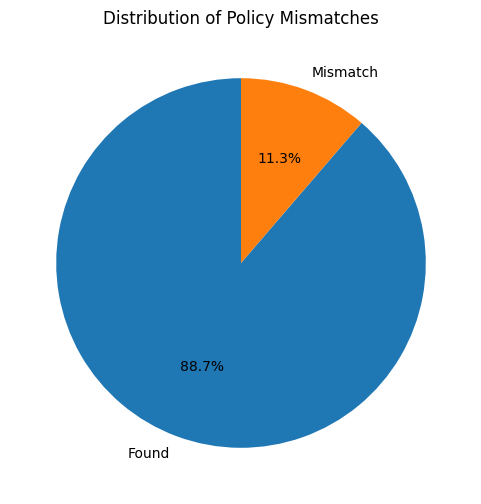

In [ ]:
#Distribution of Policy Mismatches
#  counts
total_apps = len(df_result)
mismatch_apps = len(mismatched_df)
ok_apps = total_apps - mismatch_apps

# Pie chart
labels = ['Found', 'Mismatch']
sizes = [ok_apps, mismatch_apps]


plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Policy Mismatches")
plt.show()


### Risk level Distribution (apps)

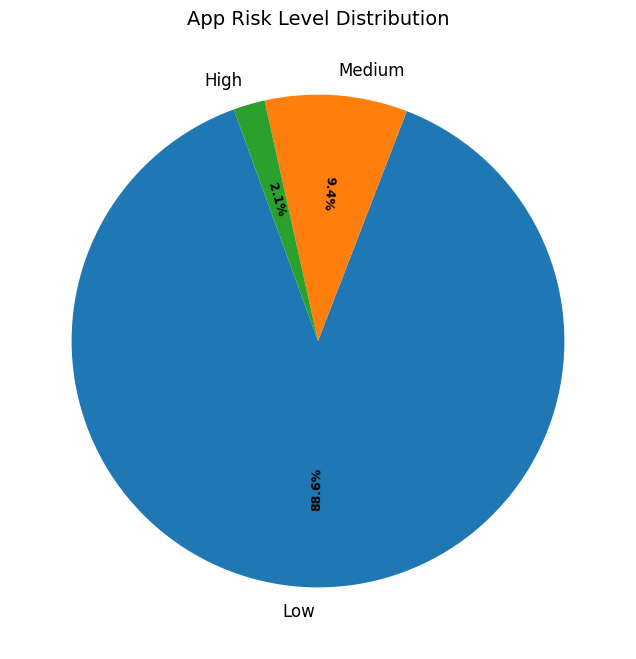

In [ ]:
# Risk level
def get_risk_level(verdict):
    if verdict.startswith("✅"):
        return "Low"
    elif verdict.startswith("⚠️"):
        return "Medium"
    elif verdict.startswith("❌"):
        return "High"
    return "Unknown"

df_result["Risk Level"] = df_result["Verdict"].apply(get_risk_level)



#  distribution
risk_counts = df_result["Risk Level"].value_counts()

# customize
def autopct_format(pct):
    return f"{pct:.1f}%" if pct > 0 else ""
plt.figure(figsize=(8,8))

# pie chart
wedges, texts, autotexts = plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct=autopct_format,
    startangle=110,
    labeldistance=1.1,
    pctdistance=0.6)

for autotext, wedge in zip(autotexts, wedges):   #rotate text
    angle = (wedge.theta2 + wedge.theta1) / 2
    autotext.set_rotation(angle - 180)
    autotext.set_ha('center')
    autotext.set_va('center')

plt.setp(texts, size=12)
plt.setp(autotexts, size=9, weight="bold")

plt.title("App Risk Level Distribution", fontsize=14)
plt.show()

### Permission-Policy Mismatch Distribution





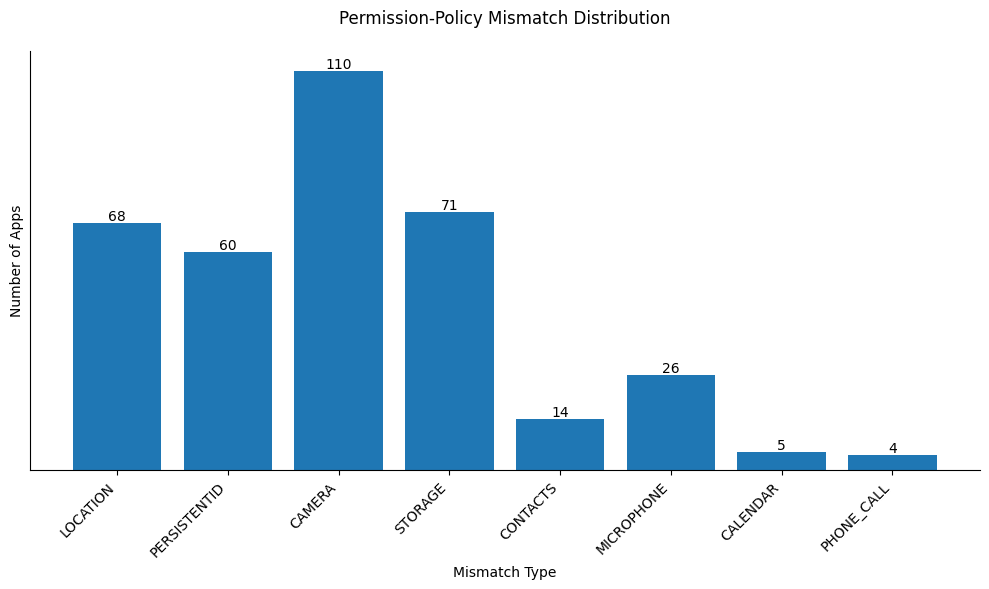

In [ ]:
# All mismatch
all_mismatches = []
for x in mismatched_df["Policy Mismatches"]:
    if isinstance(x, list):
        all_mismatches.extend(x)
    else:
        all_mismatches.append(x)

counts = Counter(all_mismatches)

# Bar plot
plt.figure(figsize=(10,6))
bars = plt.bar(counts.keys(), counts.values())

# Remove y-axis ticks
plt.yticks([])

# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.title("Permission-Policy Mismatch Distribution", pad=20)
plt.xlabel("Mismatch Type")
plt.ylabel("Number of Apps")  # optional

# Hide top and right spines (box)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("Permission-Policy Mismatch Distribution.png", dpi=300, bbox_inches='tight')

plt.show()


### Permission Analysis

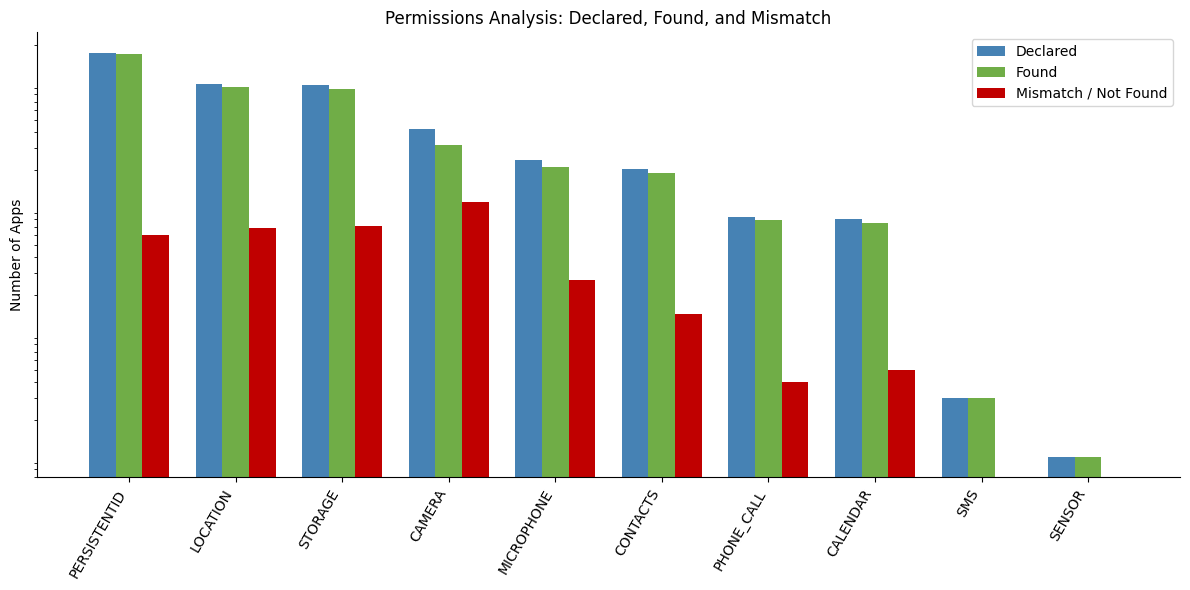

In [ ]:
# Convert string lists to lists
df_result["Policy Mismatches"] = df_result["Policy Mismatches"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_result["Permissions Used"] = df_result["Permissions Used"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_result["Permissions Found"] = df_result["Permissions Found"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

total_apps = len(df_result)

# occurrences per permission
def count_occurrences(column):
    counter = Counter()
    for lst in column:
        counter.update(lst)
    return counter

used_counts = count_occurrences(df_result["Permissions Used"])
found_counts = count_occurrences(df_result["Permissions Found"])
mismatch_counts = count_occurrences(df_result["Policy Mismatches"])

# df to plot
permissions = list(set(used_counts.keys()) | set(found_counts.keys()) | set(mismatch_counts.keys()))
plot_df = pd.DataFrame({
    'Permission': permissions,
    'Declared': [used_counts.get(p, 0) for p in permissions],
    'Found': [found_counts.get(p, 0) for p in permissions],
    'Mismatch_Not_Found': [mismatch_counts.get(p, 0) for p in permissions]
})


# Sort permissions by total count
plot_df['Total'] = plot_df['Declared'] + plot_df['Found'] + plot_df['Mismatch_Not_Found']
plot_df = plot_df.sort_values('Total', ascending=False)
plot_df.reset_index(drop=True, inplace=True)

x = np.arange(len(plot_df['Permission']))
width = 0.25

fig, ax = plt.subplots(figsize=(max(12, len(plot_df)*0.5), 6))

ax.bar(x - width, plot_df['Declared'], width, label='Declared', color='steelblue')  # Blue
ax.bar(x, plot_df['Found'], width, label='Found', color='#70AD47')  # Green
ax.bar(x + width, plot_df['Mismatch_Not_Found'], width, label='Mismatch / Not Found', color='#C00000')  # Dull Red

ax.set_xticks(x)
ax.set_xticklabels(plot_df['Permission'], rotation=60, ha='right')
ax.set_ylabel('Number of Apps')
ax.set_yscale('log')
plt.yticks([])
ax.set_title('Permissions Analysis: Declared, Found, and Mismatch')
ax.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("Permissions Analysis.png", dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
# Build summary table
summary_data = []
all_perms = set(list(used_counts.keys()) + list(found_counts.keys()) + list(mismatch_counts.keys()))

for perm in all_perms:
    declared = used_counts.get(perm, 0)
    found = found_counts.get(perm, 0)
    mismatched = mismatch_counts.get(perm, 0)

    summary_data.append({
        "Permission": perm,
        "Total Declared": f"{declared:,}",
        "% of Total Apps": f"{declared / total_apps * 100:.2f}",
        "Total Found": f"{found:,}",
        "% Found of Declared": f"{(found / declared * 100) if declared > 0 else 0:.2f}",
        "Total Mismatched": f"{mismatched:,}",
        "% Mismatch of Declared": f"{(mismatched / declared * 100) if declared > 0 else 0:.2f}"
    })

summary_df = pd.DataFrame(summary_data).sort_values(by="% of Total Apps", ascending=False)

# string lists to numeric
numeric_cols_calc = ["Total Declared", "Total Found", "Total Mismatched", "% of Total Apps", "% Found of Declared", "% Mismatch of Declared"]
summary_df_calc = summary_df.copy()
for col in numeric_cols_calc:
    summary_df_calc[col] = summary_df_calc[col].str.replace(",", "").astype(float)

# totals and averages
totals = summary_df_calc[["Total Declared", "Total Found", "Total Mismatched"]].sum()

total_row = {
    "Permission": "TOTAL",
    "Total Declared": f"{int(totals['Total Declared']):,}",
    "Total Found": f"{int(totals['Total Found']):,}",
    "Total Mismatched": f"{int(totals['Total Mismatched']):,}",
    "% of Total Apps": '',
    "% Found of Declared": '',
    "% Mismatch of Declared": ''
}


summary_df = pd.concat([summary_df, pd.DataFrame([total_row])], ignore_index=True)
summary_df


,Permission,Total Declared,% of Total Apps,Total Found,% Found of Declared,Total Mismatched,% Mismatch of Declared
0,PERSISTENTID,"1,732",96.98,"1,672",96.54,60,3.46
1,LOCATION,978,54.76,910,93.05,68,6.95
2,STORAGE,954,53.42,883,92.56,71,7.44
3,PHONE_CALL,83,4.65,79,95.18,4,4.82
4,CALENDAR,80,4.48,75,93.75,5,6.25
5,CAMERA,426,23.85,316,74.18,110,25.82
6,MICROPHONE,237,13.27,211,89.03,26,10.97
7,CONTACTS,202,11.31,188,93.07,14,6.93
8,SMS,3,0.17,3,100.00,0,0.00
9,SENSOR,1,0.06,1,100.00,0,0.00


Top declared permissions: PERSISTENTID (97%), LOCATION (55%), and STORAGE (53%) — closely matching the benchmark top dangerous permission groups.

Bottom declared permissions: SMS (0.17%), SENSOR (0.06%), PHONE_CALL (4.65%), and CALENDAR (4.48%) — consistent with rare permissions in the benchmark.

High found rates: Most permissions declared were also found in policies, with PERSISTENTID (96.5%) and LOCATION (93%) showing strong coverage.

Notable mismatches: CAMERA (26% mismatch) and STORAGE (7.4%) indicate areas where declared permissions were less consistently reflected in policies.

Overall pattern: The dataset shows a clear distinction between commonly declared top permissions, moderately declared permissions, and rare permissions, with mismatch rates generally low except for a few cases like CAMERA.

### Categories and Permission Analysis

In [ ]:
df_result['Category'].value_counts()

,count
Category,
EDUCATION,249
BOOKS_AND_REFERENCE,115
TOOLS,102
MUSIC_AND_AUDIO,100
GAME_EDUCATIONAL,93
BUSINESS,77
ENTERTAINMENT,74
LIFESTYLE,74
PERSONALIZATION,73


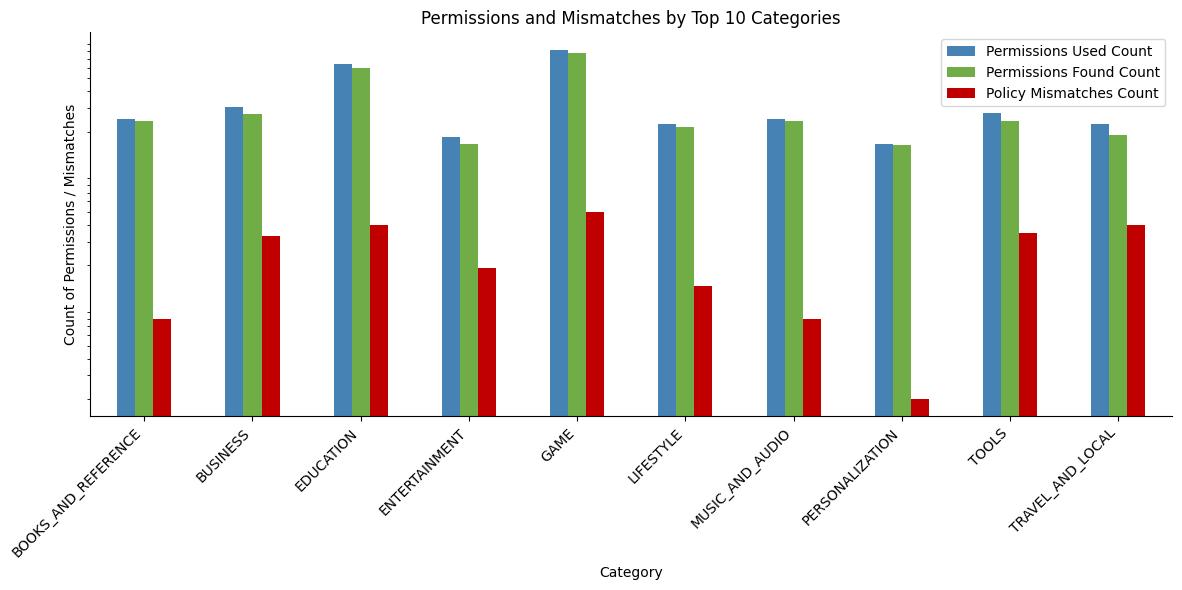

In [ ]:
# Merge GAME_* into 'GAME'
df_result['Category'] = df_result['Category'].apply(lambda x: 'GAME' if x.startswith('GAME_') else x)

# Group rare categories into 'OTHER'
threshold = 15
df_result_counts = df_result['Category'].value_counts()
rare_cats = df_result_counts[df_result_counts < threshold].index
df_result['Category'] = df_result['Category'].apply(lambda x: 'OTHER' if x in rare_cats else x)

# Pick top 10 categories by number of apps
top_categories = df_result['Category'].value_counts().nlargest(10).index
df_top10 = df_result[df_result['Category'].isin(top_categories)]


# Add counts per app
df_result['Permissions Found Count'] = df_result["Permissions Found"].apply(len)
df_result['Permissions Used Count'] = df_result["Permissions Used"].apply(len)
df_result['Policy Mismatches Count'] = df_result["Policy Mismatches"].apply(len)

#  sums per category
df_perm_plot = df_top10.groupby('Category')[[
    'Permissions Used Count', 'Permissions Found Count', 'Policy Mismatches Count'
]].sum()


#  blue, green, dull red
colors = ['steelblue', '#70AD47', '#C00000']  # Declared, Found, Mismatch

ax = df_perm_plot.plot(kind='bar', figsize=(12,6), color=colors)
plt.title("Permissions and Mismatches by Top 10 Categories")
plt.ylabel("Count of Permissions / Mismatches")

ax.set_yscale('log')
plt.yticks([])
plt.xticks(rotation=45, ha='right')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Save figure
plt.savefig("Top10_Categories_Permissions_Mismatches.png", dpi=300, bbox_inches='tight')

plt.show()


### Categories and Risk Level

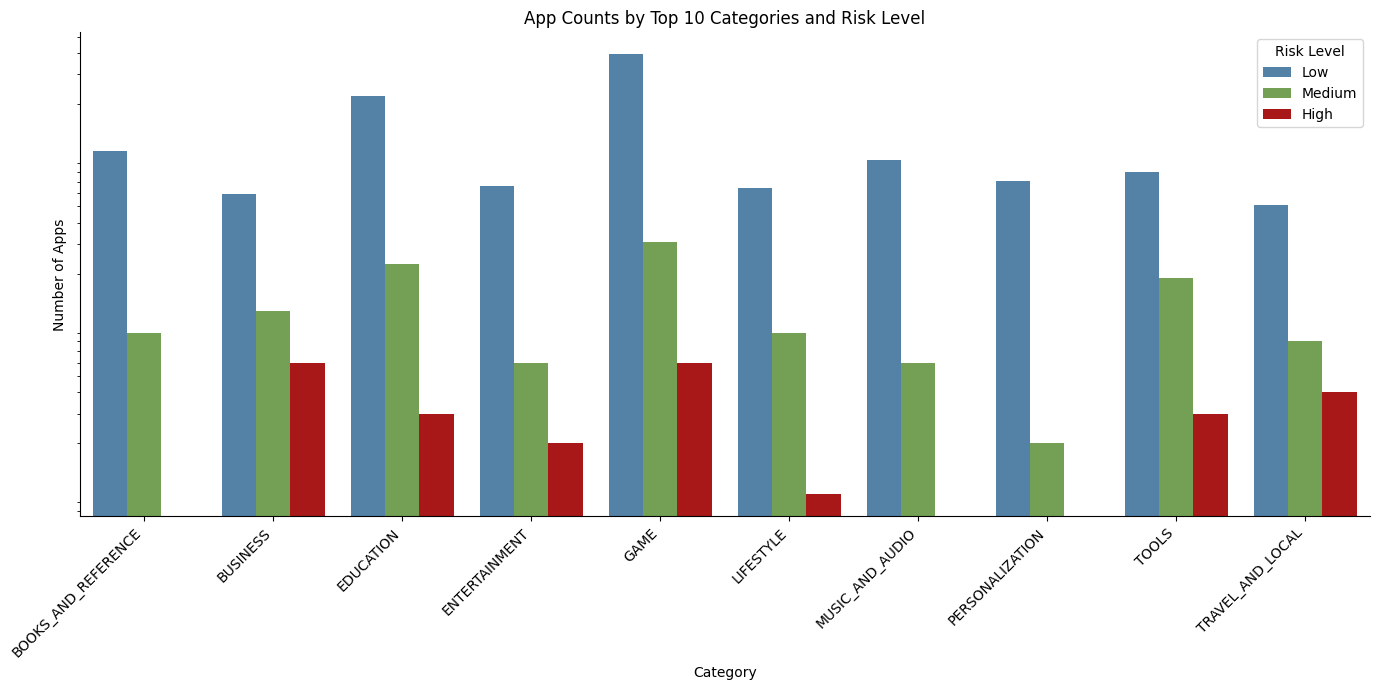

In [ ]:
# Count apps per Category and Risk Level
df_plot = df_top10.groupby(['Category', 'Risk Level']).size().reset_index(name='Count')

# colors for risk levels
risk_colors = {
    'Low': 'steelblue',
    'Medium': '#70AD47',
    'High': '#C00000'
}

# Plot
plt.figure(figsize=(14,7))
sns.barplot(
    data=df_plot,
    x='Category',
    y='Count',
    hue='Risk Level',
    palette=risk_colors
)

ax = plt.gca()
ax.set_yscale('log')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("App Counts by Top 10 Categories and Risk Level")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Apps")
plt.yticks([])

plt.tight_layout()
plt.savefig("Top10_Categories_Risk Levels.png", dpi=300, bbox_inches='tight')
plt.show()


### Save visuals to excel

In [ ]:
# Risk summary
df_risk = pd.DataFrame({
    "Risk Level": risk_counts.index,
    "Count": risk_counts.values,
    "Percentage": [count / sum(risk_counts) * 100 for count in risk_counts]
})

# Apps summary
df_apps = pd.DataFrame({
    "Category": labels,
    "Count": sizes,
    "Percentage": [size / sum(sizes) * 100 for size in sizes]
})

df_mismatch = pd.DataFrame({
    "Mismatch Type": list(counts.keys()),
    "Count": list(counts.values())
})

# Write both sheets to one Excel file
with pd.ExcelWriter("app_risk_summary.xlsx") as writer:
    summary_df.to_excel(writer, sheet_name="Full Permission Analysis", index=False)
    df_apps.to_excel(writer, sheet_name="Apps Summary", index=False)
    df_risk.to_excel(writer, sheet_name="Risk Summary", index=False)
    df_mismatch.to_excel(writer, sheet_name="Mismatch Summary", index=False)
    df_perm_plot.to_excel(writer, sheet_name="Permission_Amalysis per Category", index=False)
    df_risk_plot.to_excel(writer, sheet_name="Risk Level per Category", index=False)

print("Summary saved to 'app_risk_summary.xlsx'")


Summary saved to 'app_risk_summary.xlsx'


In [ ]:
PARENT/
│
├── requirements.txt
├── training_files/
│   └── ...
├── output_gdpr/                  # PDFs generated from GDPR summaries
│   └── ...
└── PARENT_App/
    ├── data/
    │   ├── final_keywords.json        # created keywords per permission
    │   ├── processed_output.xlsx      # initial database of 1786 apps
    │   └── app_analysis_results.xlsx  # newly analyzed apps upon query
    ├── logistic.joblib
    ├── bert.py
    ├── gdpr.py
    ├── ui.py
    ├── app.py
    ├── utils.py
    └── logistic.py